In [3]:
from scapyter.domain.leakage_functions.leakage_functions import HammingWeight
from scapyter.domain.leakage_model.leakage_model import LeakageModel
from scapyter.ui.progressive_cpa_plotter import ProgressiveCpaPlotter
from scapyter.infrastructure.repositories.npz_progressive_cpa_result_repository import NpzProgressiveCpaResultRepository
from pathlib import Path

from scapyter.infrastructure.h5_project_file_reader import (
    H5ProjectFileReader,
)

from scapyter.domain.analysis.correlation.cpa import CpaCorrelation
from scapyter.domain.targets.targets import SboxOutput
from scapyter.domain.value_object import (
    RangeParameters,
    Range,
    DataSource,
)
from scapyter.application.analysis.correlation.progressive_correlation_service import (
    ProgressiveCorrelationService,
)
from scapyter.domain.analysis.correlation.value_objects.correlation_functions import (
    CorrelationFunction,
)


file_path = "../../data/smart-card-project/smart_card_project.sx"

trace_repo = H5ProjectFileReader(file_path)

range_parameter = RangeParameters(
    trace_range=Range(0, 50),
    sample_range=Range(0, 44613),
)

correlation_functions = [
    CorrelationFunction(
        correlation=CpaCorrelation(),
        leakage_model=LeakageModel(
            target=SboxOutput(),
            leakage_function=HammingWeight(),
            byte_location=i,
        ),
    )
    for i in range(2)
]
service = ProgressiveCorrelationService(
    range_parameters=range_parameter,
    project_file_reader=trace_repo,
    data_source=DataSource.PLAINTEXT,
)

result_repository = NpzProgressiveCpaResultRepository(
    Path("../../data/smart-card-project/progressive-cpa")
)


for correlation_function in correlation_functions:
    for result in service.run(
        correlation_function=correlation_function,
        progress_steps=10,
    ):
        result_repository.save(result)

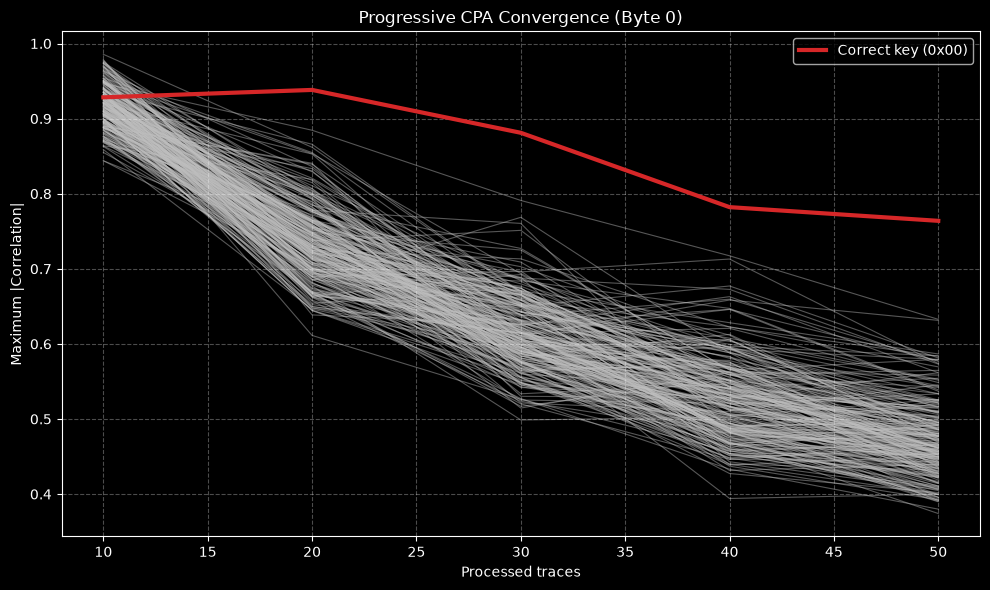

<Axes: title={'center': 'Progressive CPA Convergence (Byte 0)'}, xlabel='Processed traces', ylabel='Maximum |Correlation|'>

In [6]:
# Load saved progressive results for byte 0
byte_0_results = result_repository.load_all(byte_index=0)

plotter = ProgressiveCpaPlotter(byte_0_results)

plotter.plot_convergence(
    byte_index=0,
    correct_key=0x00,
)

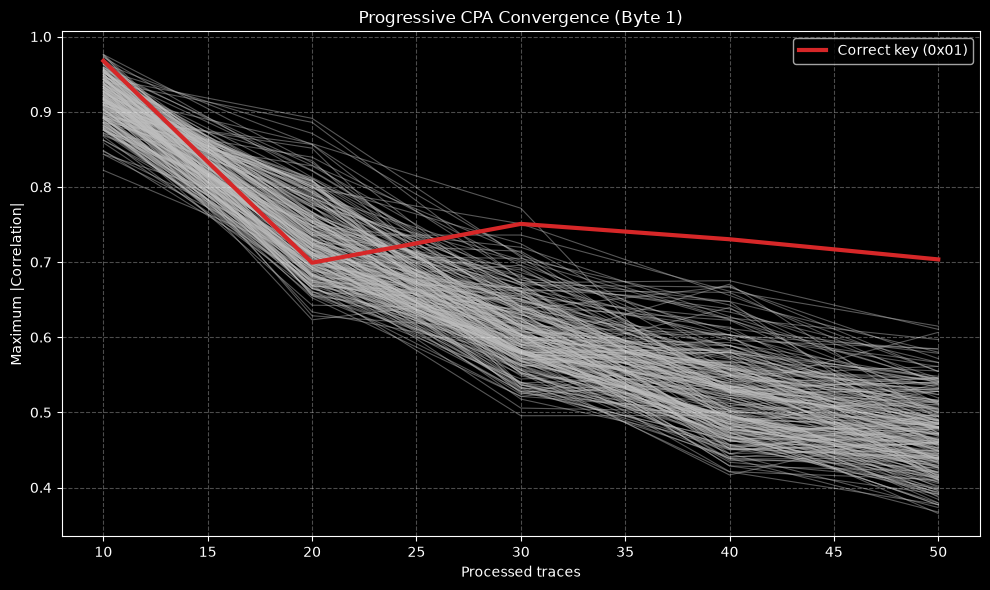

<Axes: title={'center': 'Progressive CPA Convergence (Byte 1)'}, xlabel='Processed traces', ylabel='Maximum |Correlation|'>

In [7]:
byte_1_results = result_repository.load_all(byte_index=1)
plotter = ProgressiveCpaPlotter(byte_1_results)

plotter.plot_convergence(
    byte_index=1,
    correct_key=0x01,
)